In [5]:
# Notebook assumes hypo71py is installed in the current environment.
# If running from a development clone: pip install -e .


# hypo71py — Demonstration Notebook

**hypo71py** is a Python implementation of the classic HYPO71 earthquake location algorithm — a Geiger-style iterative least-squares inversion that locates local earthquakes in a 1-D layered crustal velocity model.

---

## Overview

This notebook demonstrates three ways of using `hypo71py`, progressing from controlled synthetic tests to real catalog data:

### 1. Synthetic example
A known hypocenter is placed inside a ring of synthetic stations and exact P and S travel times are computed using the forward model.  Optional **Gaussian timing noise** is added to the picks to simulate realistic pick uncertainty (e.g. from an automatic picker).  The true location, velocity model, and noise level are all under our control, so we can evaluate location accuracy directly.

To represent **incomplete knowledge of the subsurface** — the usual situation in practice — the velocity model used for the *inverse problem* (location) is randomly perturbed from the model used to generate the synthetic data.  Depths and P-wave velocities are shifted by small fractional amounts; Vs is derived from the perturbed Vp via a fixed Vp/Vs ratio.  This tests how sensitive the location is to velocity model errors.

### 2. S-P interval location
Rather than using absolute P and S arrival times (which require accurate origin time and station clocks), `hypo71py` supports location from **S–P differential times** (`use_s_minus_p=True`).  The origin time cancels from every observation equation, leaving only three unknowns (lon, lat, depth).  This makes the solution immune to common-mode clock drift and is the preferred approach when absolute timing is unreliable.

### 3. Apollo Bay aftershocks (real data)
The 2023 $M_L$ 5.0 earthquake near Apollo Bay, Victoria produced a sequence of aftershocks detected and initially located by SeisBench/PyOcto.  This notebook re-locates the catalog (~92 events) using `hypo71py` with a regional 1-D velocity model.  

**Performance**: the full catalog relocates in **under one second** on a laptop (≈ 370 ms wall time for 92 events, using the compiled Fortran f2py travel-time kernel).  This makes `hypo71py` practical for catalog-scale relocation pipelines.

---

In [6]:
import sys
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read_events, UTCDateTime, read_inventory

from hypo71py.core import single
from hypo71py.model.velocity_model import (
    CrustalVelocityModel,
    plot_velocity_models,
    load_velocity_model_from_csv,
)
from hypo71py.model.station_phase import (
    Station,
    StationPhases,
    PhasePick,
    build_pick_dict_from_event,
)
from hypo71py.model.simple_geotools import lonlat_to_utm, get_utm_spec
from hypo71py.interface.obspy import (
    load_stations_from_stationxml,
    match_stations_to_picks,
    relocate_event_obspy,
    relocate_catalog_obspy,
)

SEED = 42   # global random seed for reproducibility
RNG  = np.random.default_rng(SEED)


## 1. Synthetic Example

### Setup

A small ring of `n_stations` synthetic stations is placed around a known hypocenter (`true_lon`, `true_lat`, `true_depth`).  Exact P and S travel times are computed from the true hypocenter to each station using `CrustalVelocityModel.calc_min_tt`, then converted to absolute arrival times by adding the true origin time.

**Pick noise** (`noise_level` seconds, Gaussian) is added independently to each P and S arrival to simulate realistic pick uncertainty.  At `noise_level = 0` the picks are exact; larger values mimic noisier automatic picks.

The `SEED` / `RNG` variables at the top of the imports cell make all random draws reproducible.

In [7]:
# --- Define simple crustal velocity model ---
vos = 1.73
depths = np.array([0.0, 2.5, 5.0, 15.0, 25.0])    # layer tops in km
vp = np.array([4.5, 5.0, 6.2, 8.0, 8.0])           # km/s
vs = vp/vos
#vs = [2.8, 3.2, 3.6, 4.6, 4.6]           # km/s
velocity_model = CrustalVelocityModel(depths, vp, vs, name="simple")
print("Velocity model initialized:", velocity_model.name)

# --- True earthquake parameters ---
true_lat  = -37.50
true_lon  = 146.50
true_depth = 10.0    # km
origin_time = UTCDateTime("2025-01-01T00:00:00")
zone, hemi = get_utm_spec(true_lon,true_lat )
utm_spec = f"UTM{zone:02d}{hemi}"  # e.g. "UTM55S"


# --- Build station geometry ---
n_stations = 5
radius_km = 20.0
include_center = False
km_per_deg = 111.0
noise_level = 0.1  # seconds
start_dist = 10.0
start_lat  = true_lat + start_dist/km_per_deg
start_lon  = true_lon + start_dist/km_per_deg

angles = np.linspace(0, 2*np.pi, n_stations, endpoint=False)
if include_center:
    angles = np.append(angles, [None])  # one at epicenter

stations = []
pick_dict = {}

for i, theta in enumerate(angles):
    if theta is None:
        lat, lon = true_lat, true_lon
    else:
        dlat = (radius_km / km_per_deg) * np.cos(theta)
        dlon = (radius_km / (km_per_deg * np.cos(np.deg2rad(true_lat)))) * np.sin(theta)
        lat = true_lat + dlat
        lon = true_lon + dlon
    code = f"STA{i+1}"
    stations.append(Station(code, lon, lat, elevation=0.1))



Velocity model initialized: simple


In [8]:
station_lons = [s.lon for s in stations]
station_lats = [s.lat for s in stations]
stat_x_m, stat_y_m = lonlat_to_utm(station_lons, station_lats, utm_spec=utm_spec)
eq_x_m, eq_y_m = lonlat_to_utm([true_lon], [true_lat], utm_spec=utm_spec)

stat_x = np.asarray(stat_x_m) / 1000.0
stat_y = np.asarray(stat_y_m) / 1000.0
eq_x = float(eq_x_m[0]) / 1000.0
eq_y = float(eq_y_m[0]) / 1000.0
eq_z = float(true_depth)

# --- Distances (km) ---
Repi = np.sqrt((stat_x - eq_x) ** 2 + (stat_y - eq_y) ** 2)
stat_depths = np.zeros_like(Repi)

# --- Synthetic pick dictionary ---
pick_dict = {}


for k, sta in enumerate(stations):
    tp, _ = velocity_model.calc_min_tt(eq_z, stat_depths[k], Repi[k], wave="P")
    ts, _ = velocity_model.calc_min_tt(eq_z, stat_depths[k], Repi[k], wave="S")

    # Add random Gaussian noise
    tp_obs = tp + RNG.normal(0, noise_level)
    ts_obs = ts + RNG.normal(0, noise_level)

    tp_time = origin_time + tp_obs
    ts_time = origin_time + ts_obs

    # Build PhasePick objects
    p_pick = PhasePick(
        phase_name="P",
        datetime=tp_time,
        station_code=sta.code,
        station_lon=sta.lon,
        station_lat=sta.lat,
        station_altitude=sta.elevation,
    )
    s_pick = PhasePick(
        phase_name="S",
        datetime=ts_time,
        station_code=sta.code,
        station_lon=sta.lon,
        station_lat=sta.lat,
        station_altitude=sta.elevation,
    )

    pick_dict[sta.code] = {"P": p_pick, "S": s_pick}

print(f"Generated synthetic picks for {len(pick_dict)} stations.")

Generated synthetic picks for 5 stations.


### Perturbed velocity model

In a real survey the true subsurface velocity structure is never known exactly.  To simulate this, `velocity_model.perturb()` creates a randomised variant of the reference model by independently shifting each layer depth (by up to `depth_factor × layer thickness`) and each Vp value (by up to `vel_factor × Vp`).  Vs is re-derived from the perturbed Vp using a fixed Vp/Vs ratio.

The perturbed model is used for **location** while the original model generated the synthetic picks — mimicking the mismatch between the assumed and true Earth structure.  Pass `seed=` for reproducible perturbations.

In [9]:
velocity_model_per = velocity_model.perturb(depth_factor=0.5,
    vel_factor=0.1,
    vpvs_scale=1.73,
    seed=42)


<Axes: xlabel='Velocity (km/s)', ylabel='Depth (km)'>

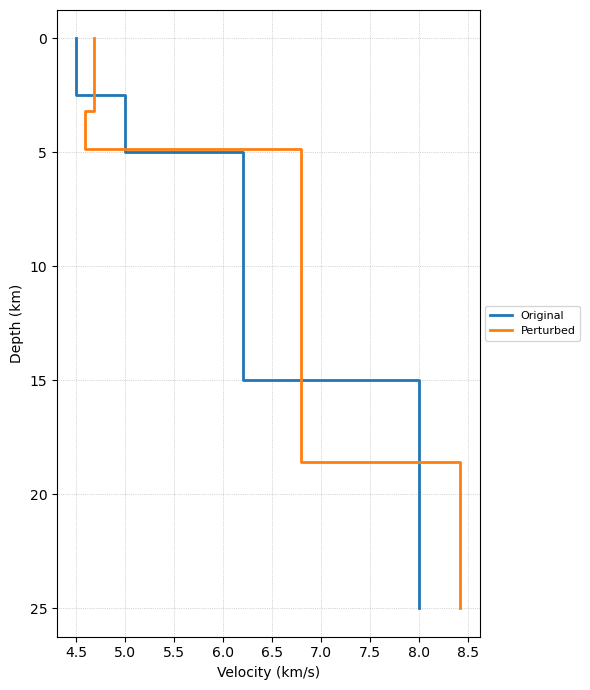

In [10]:
plot_velocity_models(
    [velocity_model, velocity_model_per],
    labels=["Original", "Perturbed"]
)

In [11]:
%%time
location_result = single.SINGLE(
    stations,
    pick_dict,
    #velocity_model,
    velocity_model_per, 
    ZTR = 15,
    max_num_iterations=100,
    origin=(start_lon, start_lat, origin_time),
     use_fortran_speedups=True,
    verbose= False)

CPU times: user 192 ms, sys: 27.4 ms, total: 219 ms
Wall time: 40.6 ms


In [12]:
# Accessing individual elements
loc_lon = location_result[0]
loc_lat = location_result[1]
loc_depth = location_result[2]
ORG = location_result[3]
SE = location_result[4]
station_phases= location_result[5]
QSD = location_result[6]
NI = location_result[7]
RMS = location_result[-1]

In [13]:
print(RMS, NI, loc_depth, ORG)

0.10557903 5 16.43306 2024-12-31T23:59:59.982321Z


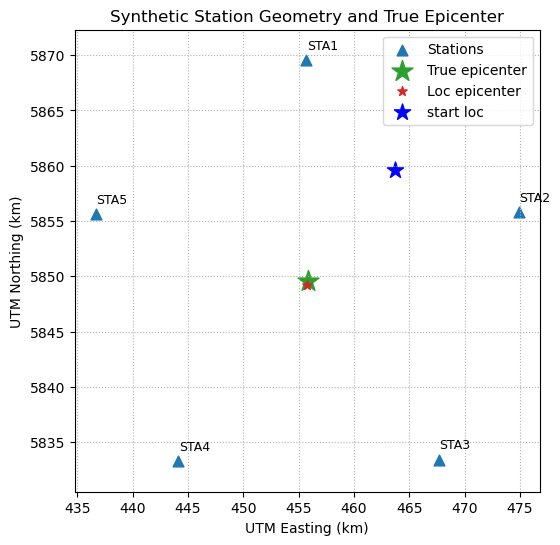

In [14]:

# --- Convert epicenter and stations to UTM (in km) ---
station_lons = [s.lon for s in stations]
station_lats = [s.lat for s in stations]
stat_x, stat_y = lonlat_to_utm(station_lons, station_lats, utm_spec=utm_spec)
stat_x = np.array(stat_x) / 1000.0
stat_y = np.array(stat_y) / 1000.0

eq_x, eq_y = lonlat_to_utm([true_lon], [true_lat], utm_spec=utm_spec)
eq_x, eq_y = eq_x[0] / 1000.0, eq_y[0] / 1000.0

# --- Plot geometry ---
plt.figure(figsize=(6, 6))
plt.scatter(stat_x, stat_y, c='tab:blue', s=60, marker = '^', label='Stations')

plt.scatter(eq_x, eq_y, c='tab:green', marker='*', s=250, label='True epicenter')

loc_x, loc_y = lonlat_to_utm(loc_lon, loc_lat, utm_spec=utm_spec)
loc_x, loc_y = loc_x/1000.0, loc_y/1000.0
plt.scatter(loc_x, loc_y, c='tab:red', marker='*', s=50, label='Loc epicenter')


start_x, start_y = lonlat_to_utm(start_lon, start_lat, utm_spec=utm_spec)
start_x, start_y = start_x/1000.0, start_y/1000.0
plt.scatter(start_x, start_y, c='blue', marker='*', s=150, label='start loc')

for i, s in enumerate(stations):
    plt.text(stat_x[i] + 0.04, stat_y[i] + 1, s.code, fontsize=9)

#plt.scatter(xs, ys, c=fvals,
#            cmap='viridis', s=10, alpha=0.8)

plt.xlabel("UTM Easting (km)")
plt.ylabel("UTM Northing (km)")
plt.title("Synthetic Station Geometry and True Epicenter")
plt.axis('equal')
plt.grid(True, ls=':')
plt.legend()
plt.show()

In [15]:
#stations
loc_x - eq_x

np.float64(-0.06749402491141154)

In [16]:
%%time
depths = np.linspace(0, 15, 41)  # 0, 0.5, 1.0, …, 10 km
rms_values = []

for d in depths:
    location_result_ = single.SINGLE(
        stations,
        pick_dict,
        #velocity_model,
        velocity_model_per, 
        ZTR = d, 
        origin=None,
        #origin=(start_lon, start_lat, origin_time),
        fix_depth= True, 
        use_fortran_speedups=True,
        verbose= False);
    
    rms = location_result_[-1]
    rms_values.append(rms)
    #print(f"Depth = {d:.1f} km → RMS = {rms:.4f}")



CPU times: user 270 ms, sys: 245 ms, total: 515 ms
Wall time: 249 ms


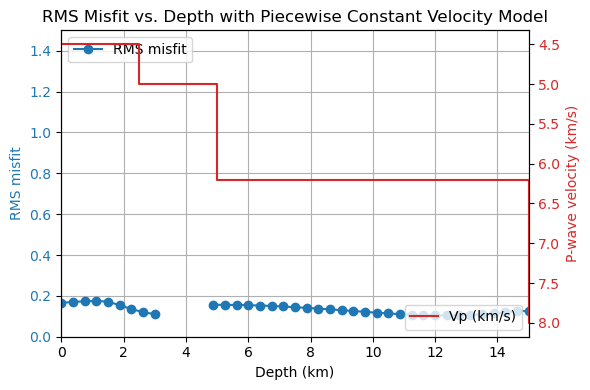

In [17]:
# Extract layer tops/bottoms and velocities
depth_model = np.asarray(velocity_model.depths)  # e.g. [0, 1, 2, 4, 8, 20]
vp_model = np.asarray(velocity_model.VP)         # e.g. [5.0, 5.5, 6.0, 6.7, 7.8]

# Ensure same number of interfaces
if len(vp_model) == len(depth_model) - 1:
    # Standard case: velocities correspond to layers between boundaries
    depth_steps = np.repeat(depth_model, 2)[1:-1]
    vp_steps = np.repeat(vp_model, 2)
else:
    # If same length, assume each depth has a defined vp (continuous)
    depth_steps = np.repeat(depth_model, 2)[1:-1]
    vp_steps = np.repeat(vp_model, 2)[0:len(depth_steps)]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(6, 4))

# RMS misfit curve
ax1.plot(depths, rms_values, marker='o', color='tab:blue', label='RMS misfit')
ax1.set_xlabel("Depth (km)")
ax1.set_ylabel("RMS misfit", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)
ax1.set_xlim(0, 15)
ax1.set_ylim(0,1.5)

# Velocity model (piecewise constant)
ax2 = ax1.twinx()
ax2.step(depth_steps, vp_steps, where='post', color='tab:red', label='Vp (km/s)')
ax2.invert_yaxis()
ax2.set_ylabel("P-wave velocity (km/s)", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combine legends and title
ax1.legend(loc='upper left')
ax2.legend(loc='lower right')
plt.title("RMS Misfit vs. Depth with Piecewise Constant Velocity Model")
fig.tight_layout()
plt.show()

In [18]:
(loc_lon , loc_lat, ORG)

(np.float64(146.49921483181552),
 np.float64(-37.50323156877656),
 2024-12-31T23:59:59.982321Z)

## S-P Location

In S-P mode (`use_s_minus_p=True`) the **origin time cancels** from every observation equation.  Each station contributes an S–P interval observation:

$$\Delta t_{SP} = t_S - t_P = \left(\frac{V_P}{V_S} - 1\right) \cdot T_P(\mathbf{x})$$

where $T_P(\mathbf{x})$ is the predicted P travel time from the current trial hypocenter.  Because origin time does not appear, the inversion solves only for **(lon, lat, depth)** — 3 unknowns instead of 4.  `min_num_phases=3` is therefore the appropriate minimum (the default of 4 is calibrated for the absolute P+S case).

**Trade-off**: the absolute origin time is no longer determined by the data.

In [19]:
location_result_smp = single.SINGLE(
    stations,
    pick_dict,
    #velocity_model,
    velocity_model_per, 
    ZTR=5,
    origin=(start_lon, start_lat, origin_time),
    use_s_minus_p=True,
    use_s_picks=False,
    min_num_phases=3,        # S-P: 3 unknowns (x, y, z); origin time not constrained
    use_fortran_speedups=True,
    verbose=False,
)

loc_lon_smp, loc_lat_smp, loc_depth_smp = (
    location_result_smp[0], location_result_smp[1], location_result_smp[2]
)
rms_smp = location_result_smp[8]

In [20]:
# Compare: true location / absolute P+S / S-P
rows = [
    ("True",       true_lon, true_lat, true_depth, "—"),
    ("Absolute",   loc_lon,  loc_lat,  loc_depth,  f"{rms:.4f}"),
    ("S-P",        loc_lon_smp, loc_lat_smp, loc_depth_smp, f"{rms_smp:.4f}"),
]

print(f"{'Locator':<12} {'Lon (°)':>10} {'Lat (°)':>10} {'Depth (km)':>12} {'RMS (s)':>10}")
print("-" * 58)
for name, lon, lat, dep, rms_str in rows:
    print(f"{name:<12} {lon:>10.5f} {lat:>10.5f} {dep:>12.3f} {rms_str:>10}")

print()
print(f"{'Δ vs True':<12} {'Δlon (°)':>10} {'Δlat (°)':>10} {'Δdepth (km)':>12}")
print("-" * 48)
for name, lon, lat, dep, _ in rows[1:]:
    print(f"{name:<12} {lon-true_lon:>+10.5f} {lat-true_lat:>+10.5f} {dep-true_depth:>+12.3f}")

Locator         Lon (°)    Lat (°)   Depth (km)    RMS (s)
----------------------------------------------------------
True          146.50000  -37.50000       10.000          —
Absolute      146.49921  -37.50323       16.433     0.1250
S-P           146.49412  -37.49262        5.000     0.4090

Δ vs True      Δlon (°)   Δlat (°)  Δdepth (km)
------------------------------------------------
Absolute       -0.00079   -0.00323       +6.433
S-P            -0.00588   +0.00738       -5.000


In [21]:
def jitter_picks(pick_dict_in, sigma_clock=0.02, rng=None):
    """
    Apply a single Gaussian clock drift (seconds) per station.
    Both P and S picks at that station are shifted by the same amount.

    Parameters
    ----------
    pick_dict_in : dict
        Original pick dictionary {station: {'P': PhasePick, 'S': PhasePick}}
    sigma_clock : float
        Standard deviation of the station clock drift (seconds)
    rng : np.random.Generator, optional
        Random generator (for reproducibility)

    Returns
    -------
    dict
        Deep-copied and time-shifted pick_dict
    """
    if rng is None:
        rng = np.random.default_rng()
    pd = deepcopy(pick_dict_in)

    for sta, phases in pd.items():
        drift = float(rng.normal(0.0, sigma_clock))  # one offset per station
        for phase in ("P", "S"):
            if phase in phases and phases[phase] is not None:
                phases[phase].datetime += drift

    return pd

### Clock-drift robustness

A key practical advantage of S-P location is **immunity to common-mode timing errors**.  If a station's clock drifts by $\delta$ seconds, both the P and S arrival times shift by the same $\delta$, so the S-P interval $t_S - t_P$ is unchanged.

`jitter_picks` simulates this: it applies a single random offset per station to **both** P and S, exactly mimicking a clock drift.  The table below will show that $\Delta t_{SP} \approx 0$ across all stations even when $|\Delta t_P|$ and $|\Delta t_S|$ are large — and consequently the S-P location should be nearly identical to the unperturbed result.

In [22]:
pick_dict_perturb = jitter_picks(
    pick_dict,
    sigma_clock=0.05,
    rng=np.random.default_rng(SEED),
)


In [23]:
# Show the effect of clock drift on absolute and S-P pick times.
# ΔP ≈ ΔS ≈ clock offset; Δ(S-P) ≈ 0 — the S-P interval is unaffected.
print(f"{'Station':<8} {'ΔP (s)':>8} {'ΔS (s)':>8} {'Δ(S–P) (s)':>12}  {'S–P (s)':>9}")
print("-" * 52)
for sta in pick_dict:
    p0 = pick_dict[sta]["P"].datetime
    s0 = pick_dict[sta]["S"].datetime
    p1 = pick_dict_perturb[sta]["P"].datetime
    s1 = pick_dict_perturb[sta]["S"].datetime

    dP  = float(p1 - p0)                  # clock offset applied to P
    dS  = float(s1 - s0)                  # clock offset applied to S (same value)
    dSP = float((s1 - p1) - (s0 - p0))   # change in S-P interval ≈ 0
    SmP = float(s1 - p1)                  # absolute S-P interval after jitter

    print(f"{sta:<8} {dP:>+8.3f} {dS:>+8.3f} {dSP:>+12.4f}  {SmP:>9.4f}")

Station    ΔP (s)   ΔS (s)   Δ(S–P) (s)    S–P (s)
----------------------------------------------------
STA1       +0.015   +0.015      +0.0000     2.8137
STA2       -0.052   -0.052      +0.0000     2.9765
STA3       +0.038   +0.038      +0.0000     3.0156
STA4       +0.047   +0.047      +0.0000     2.9064
STA5       -0.098   -0.098      +0.0000     2.8740


In [24]:
location_result_smp_perturb = single.SINGLE(
    stations,
    pick_dict_perturb,
    #velocity_model,
    velocity_model_per, 
    ZTR=5,
    origin=(start_lon, start_lat, origin_time),
    use_s_minus_p=True,
    use_s_picks=False,
    min_num_phases=3,
    use_fortran_speedups=True,
    verbose=False,
)

loc_lon_smp_perturb   = location_result_smp_perturb[0]
loc_lat_smp_perturb   = location_result_smp_perturb[1]
loc_depth_smp_perturb = location_result_smp_perturb[2]
rms_smp_perturb       = location_result_smp_perturb[8]

In [25]:
# S-P clean vs S-P jittered — clock drift should have negligible effect
rows2 = [
    ("True",         true_lon,             true_lat,             true_depth,             "—"),
    ("Absolute",     loc_lon,              loc_lat,              loc_depth,              f"{rms:.4f}"),
    ("S-P clean",    loc_lon_smp,          loc_lat_smp,          loc_depth_smp,          f"{rms_smp:.4f}"),
    ("S-P jittered", loc_lon_smp_perturb,  loc_lat_smp_perturb,  loc_depth_smp_perturb,  f"{rms_smp_perturb:.4f}"),
]

print(f"{'Locator':<14} {'Lon (°)':>10} {'Lat (°)':>10} {'Depth (km)':>12} {'RMS (s)':>10}")
print("-" * 62)
for name, lon, lat, dep, rms_str in rows2:
    print(f"{name:<14} {lon:>10.5f} {lat:>10.5f} {dep:>12.3f} {rms_str:>10}")

print()
print(f"{'Δ vs True':<14} {'Δlon (°)':>10} {'Δlat (°)':>10} {'Δdepth (km)':>12}")
print("-" * 50)
for name, lon, lat, dep, _ in rows2[1:]:
    print(f"{name:<14} {lon-true_lon:>+10.5f} {lat-true_lat:>+10.5f} {dep-true_depth:>+12.3f}")

print()
dlon_drift  = loc_lon_smp_perturb  - loc_lon_smp
dlat_drift  = loc_lat_smp_perturb  - loc_lat_smp
ddep_drift  = loc_depth_smp_perturb - loc_depth_smp
print(f"S-P jittered vs S-P clean:  Δlon={dlon_drift:+.5f}°  Δlat={dlat_drift:+.5f}°  Δdepth={ddep_drift:+.3f} km")
print("(These should be ~0 — clock drift is absorbed by the S-P differencing)")

Locator           Lon (°)    Lat (°)   Depth (km)    RMS (s)
--------------------------------------------------------------
True            146.50000  -37.50000       10.000          —
Absolute        146.49921  -37.50323       16.433     0.1250
S-P clean       146.49412  -37.49262        5.000     0.4090
S-P jittered    146.49412  -37.49262        5.000     0.4090

Δ vs True        Δlon (°)   Δlat (°)  Δdepth (km)
--------------------------------------------------
Absolute         -0.00079   -0.00323       +6.433
S-P clean        -0.00588   +0.00738       -5.000
S-P jittered     -0.00588   +0.00738       -5.000

S-P jittered vs S-P clean:  Δlon=+0.00000°  Δlat=+0.00000°  Δdepth=+0.000 km
(These should be ~0 — clock drift is absorbed by the S-P differencing)


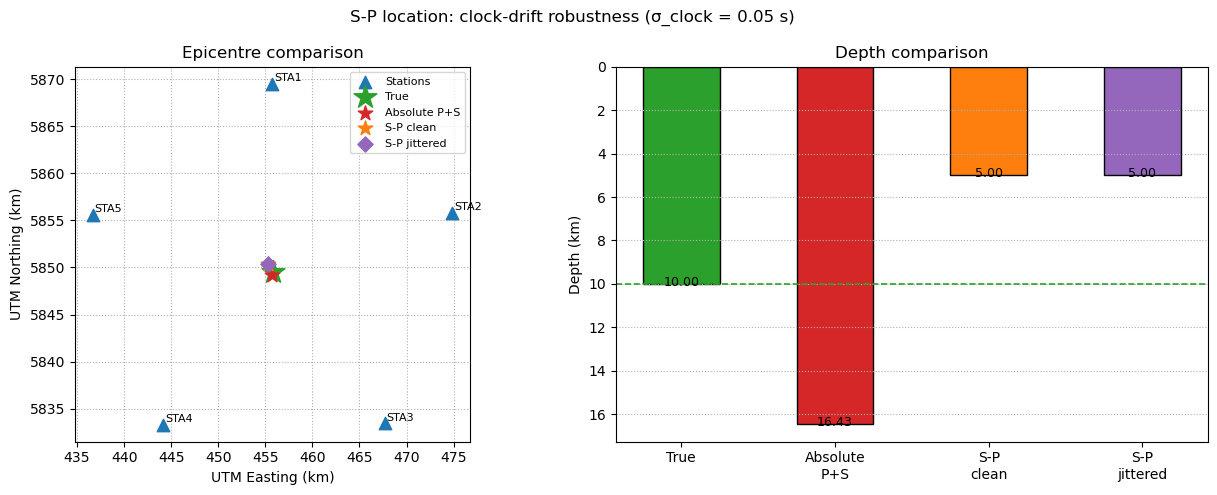

In [26]:
def to_utm_km(lon, lat):
    """Wrap lonlat_to_utm for single points, return (x_km, y_km)."""
    x, y = lonlat_to_utm([lon], [lat], utm_spec=utm_spec)
    return x[0] / 1000.0, y[0] / 1000.0

# Stations
stat_x = np.array([to_utm_km(s.lon, s.lat)[0] for s in stations])
stat_y = np.array([to_utm_km(s.lon, s.lat)[1] for s in stations])

# Hypocenters
true_x,    true_y    = to_utm_km(true_lon,            true_lat)
abs_x,     abs_y     = to_utm_km(loc_lon,             loc_lat)
smp_x,     smp_y     = to_utm_km(loc_lon_smp,         loc_lat_smp)
smpj_x,    smpj_y    = to_utm_km(loc_lon_smp_perturb, loc_lat_smp_perturb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- left: map view ----
ax = axes[0]
ax.scatter(stat_x, stat_y, marker='^', s=80, c='tab:blue', zorder=3, label='Stations')
for i, s in enumerate(stations):
    ax.text(stat_x[i] + 0.2, stat_y[i] + 0.3, s.sta, fontsize=8)

ax.scatter(true_x,  true_y,  marker='*', s=300, c='tab:green',  zorder=4, label='True')
ax.scatter(abs_x,   abs_y,   marker='*', s=120, c='tab:red',    zorder=4, label='Absolute P+S')
ax.scatter(smp_x,   smp_y,   marker='*', s=120, c='tab:orange', zorder=4, label='S-P clean')
ax.scatter(smpj_x,  smpj_y,  marker='D', s=60,  c='tab:purple', zorder=4, label='S-P jittered')

ax.set_xlabel("UTM Easting (km)")
ax.set_ylabel("UTM Northing (km)")
ax.set_title("Epicentre comparison")
ax.set_aspect('equal')
ax.grid(True, ls=':')
ax.legend(fontsize=8)

# ---- right: depth bar chart ----
ax2 = axes[1]
labels  = ['True', 'Absolute\nP+S', 'S-P\nclean', 'S-P\njittered']
depths  = [true_depth, loc_depth, loc_depth_smp, loc_depth_smp_perturb]
colors  = ['tab:green', 'tab:red', 'tab:orange', 'tab:purple']
bars    = ax2.bar(labels, depths, color=colors, edgecolor='k', width=0.5)
ax2.axhline(true_depth, color='tab:green', linestyle='--', lw=1.2, label=f'True ({true_depth} km)')
for bar, dep in zip(bars, depths):
    ax2.text(bar.get_x() + bar.get_width() / 2, dep + 0.1, f'{dep:.2f}', ha='center', fontsize=9)
ax2.set_ylabel("Depth (km)")
ax2.set_title("Depth comparison")
ax2.invert_yaxis()
ax2.grid(True, ls=':', axis='y')

plt.suptitle(f"S-P location: clock-drift robustness (σ_clock = {0.05} s)", fontsize=12)
plt.tight_layout()
plt.show()

## Real events 

- aftershocks of 2023 $M_L$ 5.0 event near Apollo Bay, Victoria

In [27]:
# Load the Apollo Bay regional velocity model
velocity_model = load_velocity_model_from_csv(
    "./data/ensemble_avg.csv", name="apollo_bay"
)
print(velocity_model)


✅ Loaded velocity model 'apollo_bay' from ./data/ensemble_avg.csv
<CrustalVelocityModel "apollo_bay" (n=5)>


In [28]:
# Load stations from StationXML
stations = load_stations_from_stationxml("./data/apollo_bay_metadata")
print(f"Loaded {len(stations)} stations: {[s.sta for s in stations]}")


Loaded 8 stations: ['ABM1Y', 'ABM2Y', 'ABM3Y', 'ABM4Y', 'ABM5Y', 'ABM6Y', 'ABM7Y', 'FRTM']


In [29]:
# --- Read the initial catalog ---

# contains events deteceted and automatically located by Seisbench/PyOcto
cat = read_events("./data/seisbench_cat.xml")

In [30]:
%%time

from hypo71py.interface.obspy import match_stations_to_picks

relocated_events = []
for i, ev in enumerate(cat, 1):
    origin_info, pick_dict, picked_station_codes = build_pick_dict_from_event(ev)

    lat0        = origin_info["latitude"]
    lon0        = origin_info["longitude"]
    depth0      = origin_info["depth_km"]
    origin_time = origin_info["time"]

    stations_subset, missing = match_stations_to_picks(stations, picked_station_codes)

    # --- Run location ---
    location_result = single.SINGLE(
        stations_subset,
        pick_dict,
        velocity_model,
        ZTR=depth0,
        origin=(lon0, lat0, origin_time),
        use_fortran_speedups=True,
        verbose=False)

    loc_lon         = location_result[0]
    loc_lat         = location_result[1]
    loc_depth       = location_result[2]
    ORG             = location_result[3]
    SE              = location_result[4]
    station_phases  = location_result[5]
    QSD             = location_result[6]
    rms             = location_result[-1]

    relocated_events.append({
        "event_id":          ev.resource_id.id,
        "original_lat":      lat0,
        "original_lon":      lon0,
        "original_depth_km": depth0,
        "relocated_lat":     loc_lat,
        "relocated_lon":     loc_lon,
        "relocated_depth_km": loc_depth,
        "rms":               rms,
        "datetime":          ORG,
    })


CPU times: user 442 ms, sys: 1.72 ms, total: 444 ms
Wall time: 443 ms


In [31]:
# Build DataFrame
df = pd.DataFrame(relocated_events)

# Convert datetime safely (ObsPy UTCDateTime → pandas Timestamp)
df["datetime"] = pd.to_datetime(df["datetime"].astype(str), errors="coerce")


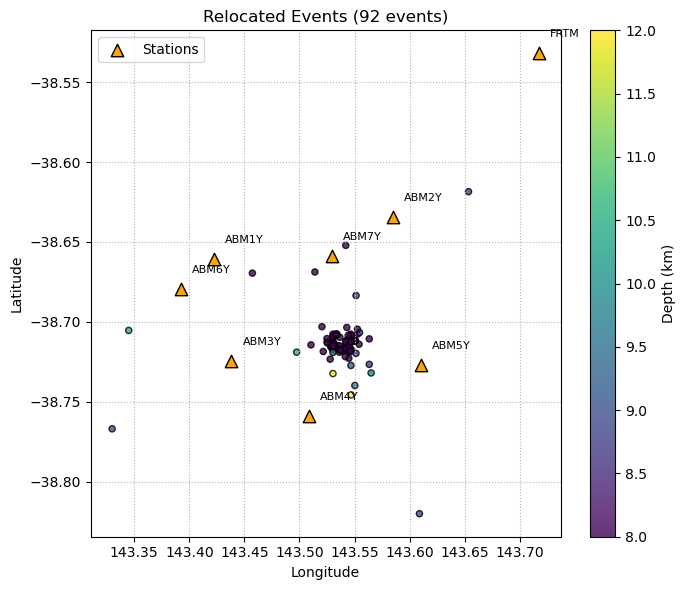

In [32]:

# Basic QC plot for relocated events
plt.figure(figsize=(7,6))
sc = plt.scatter(
    df["relocated_lon"], df["relocated_lat"],
    c=df["relocated_depth_km"] if "rms" in df.columns else "tab:red",
    cmap="viridis", s=20, edgecolor="k", alpha=0.8, vmin=8, vmax=12)
plt.colorbar(sc, label="Depth (km)")

# Overlay stations (optional)
if "stations" in locals():
    st_lons = [s.lon for s in stations]
    st_lats = [s.lat for s in stations]
    plt.scatter(st_lons, st_lats, marker="^", s=80, color="orange", edgecolor="k", label="Stations")
    for s in stations:
        plt.text(s.lon + 0.01, s.lat + 0.01, s.sta, fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Relocated Events ({len(df)} events)")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()

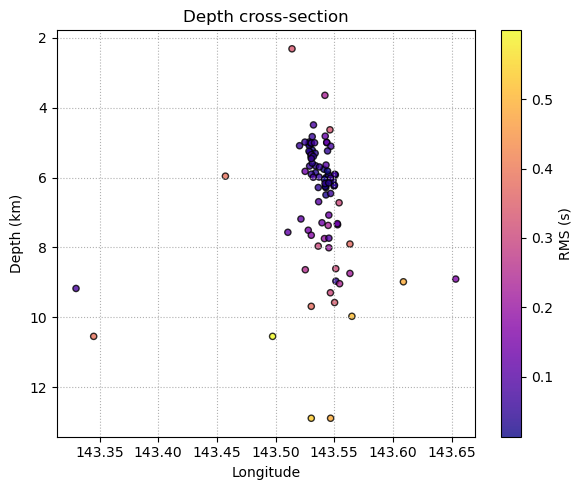

In [33]:
plt.figure(figsize=(6, 5))
plt.scatter(df["relocated_lon"], df["relocated_depth_km"],
            c=df["rms"], cmap="plasma", s=20, edgecolor="k", alpha=0.8)
plt.colorbar(label="RMS (s)")
plt.xlabel("Longitude"); plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.title("Depth cross-section"); plt.grid(ls=":"); plt.tight_layout(); plt.show()


### S-P Relocation

Run the same catalog using **S–P intervals only** (`use_s_minus_p=True`).  
The absolute origin time is not constrained by S–P data, so only epicentre and depth are compared against the absolute P+S solution.

In [34]:
%%time

# In S-P mode, origin time cancels from every observation equation,
# leaving only 3 unknowns (lon, lat, depth).  The default min_num_phases=4
# is calibrated for the absolute case (4 unknowns: x, y, z, t).
# 3 S-P pairs is geometrically sufficient → use min_num_phases=3.

relocated_events_sp = []
n_skipped_sp = 0
sp_pair_counts = []

for i, ev in enumerate(cat, 1):
    origin_info, pick_dict, picked_station_codes = build_pick_dict_from_event(ev)

    lat0        = origin_info["latitude"]
    lon0        = origin_info["longitude"]
    depth0      = origin_info["depth_km"]
    origin_time = origin_info["time"]

    stations_subset, _ = match_stations_to_picks(stations, picked_station_codes)

    n_sp_pairs = sum(
        1 for v in pick_dict.values()
        if v.get("P") is not None and v.get("S") is not None
    )
    sp_pair_counts.append(n_sp_pairs)

    if n_sp_pairs < 3:
        n_skipped_sp += 1
        continue

    try:
        location_result = single.SINGLE(
            stations_subset,
            pick_dict,
            velocity_model,
            ZTR=depth0,
            origin=(lon0, lat0, origin_time),
            use_s_minus_p=True,
            use_s_picks=False,
            min_num_phases=3,           # S-P: only 3 unknowns (x,y,z); t not constrained
            use_fortran_speedups=True,
            verbose=False)

        relocated_events_sp.append({
            "event_id":           ev.resource_id.id,
            "original_lat":       lat0,
            "original_lon":       lon0,
            "original_depth_km":  depth0,
            "sp_lat":             location_result[1],
            "sp_lon":             location_result[0],
            "sp_depth_km":        location_result[2],
            "sp_rms":             location_result[-1],
        })
    except Exception as e:
        pass

import collections
cnt = collections.Counter(sp_pair_counts)
print(f"S-P located: {len(relocated_events_sp)}  skipped (< 3 pairs): {n_skipped_sp}")
print(f"S-P pair count distribution: {dict(sorted(cnt.items()))}")

S-P located: 92  skipped (< 3 pairs): 0
S-P pair count distribution: {3: 35, 4: 28, 5: 27, 6: 2}
CPU times: user 417 ms, sys: 1.72 ms, total: 419 ms
Wall time: 418 ms


Paired events: 92
       dlon_deg  dlat_deg  ddepth_km  dhoriz_km   sp_rms
count   92.0000   92.0000    92.0000    92.0000  92.0000
mean     0.0012   -0.0004    -0.5614     1.6446   0.1444
std      0.0237    0.0148     1.4119     2.0499   0.1854
min     -0.1183   -0.0575    -7.1268     0.0769   0.0003
25%     -0.0018   -0.0038    -0.5665     0.4428   0.0350
50%      0.0021   -0.0008    -0.1196     0.7652   0.0654
75%      0.0080    0.0027     0.0865     1.8777   0.1915
max      0.0735    0.0830     1.3042    10.4727   0.8116


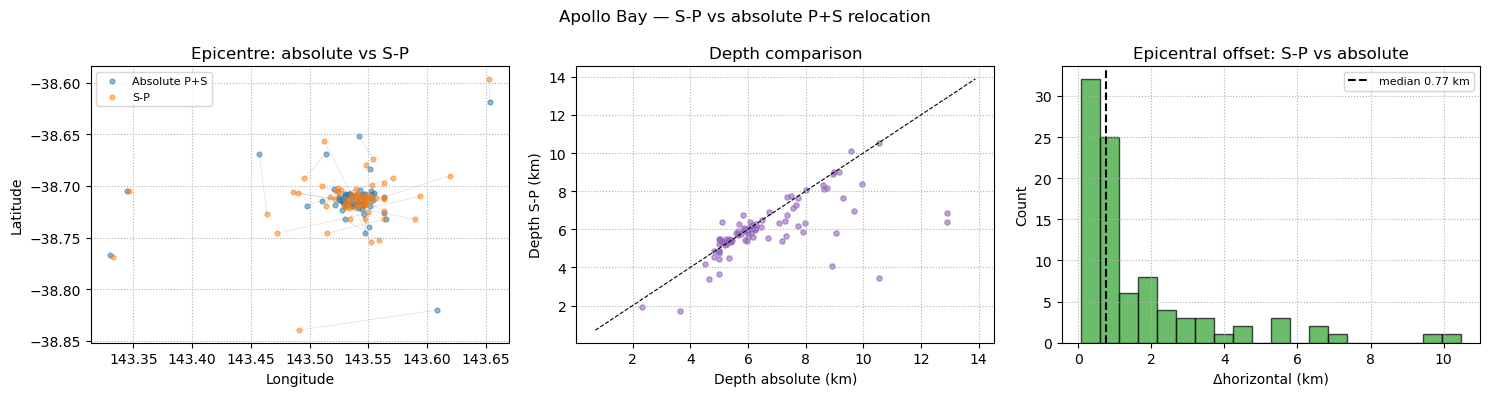

In [35]:
# Merge absolute P+S locations with S-P locations on event_id
df_abs = df[["event_id", "relocated_lon", "relocated_lat", "relocated_depth_km", "rms"]].copy()
df_sp  = pd.DataFrame(relocated_events_sp)

df_cmp = df_abs.merge(df_sp[["event_id","sp_lon","sp_lat","sp_depth_km","sp_rms"]],
                      on="event_id", how="inner")

df_cmp["dlon_deg"]   = df_cmp["sp_lon"]       - df_cmp["relocated_lon"]
df_cmp["dlat_deg"]   = df_cmp["sp_lat"]       - df_cmp["relocated_lat"]
df_cmp["ddepth_km"]  = df_cmp["sp_depth_km"]  - df_cmp["relocated_depth_km"]
df_cmp["dhoriz_km"]  = np.sqrt(
    (df_cmp["dlon_deg"] * 111.2 * np.cos(np.radians(df_cmp["relocated_lat"])))**2
    + (df_cmp["dlat_deg"] * 111.2)**2
)

print(f"Paired events: {len(df_cmp)}")
print(df_cmp[["dlon_deg","dlat_deg","ddepth_km","dhoriz_km","sp_rms"]].describe().round(4))

# ---- Comparison plot ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df_cmp["relocated_lon"], df_cmp["relocated_lat"],
                s=12, alpha=0.5, label="Absolute P+S", color="tab:blue")
axes[0].scatter(df_cmp["sp_lon"], df_cmp["sp_lat"],
                s=12, alpha=0.5, label="S-P", color="tab:orange")
for _, row in df_cmp.iterrows():
    axes[0].plot([row["relocated_lon"], row["sp_lon"]],
                 [row["relocated_lat"],  row["sp_lat"]],
                 color="grey", alpha=0.25, lw=0.5)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_title("Epicentre: absolute vs S-P"); axes[0].legend(fontsize=8)
axes[0].grid(ls=":")

axes[1].scatter(df_cmp["relocated_depth_km"], df_cmp["sp_depth_km"],
                s=14, alpha=0.6, color="tab:purple")
lim = [df_cmp[["relocated_depth_km","sp_depth_km"]].min().min() - 1,
       df_cmp[["relocated_depth_km","sp_depth_km"]].max().max() + 1]
axes[1].plot(lim, lim, "k--", lw=0.8)
axes[1].set_xlabel("Depth absolute (km)"); axes[1].set_ylabel("Depth S-P (km)")
axes[1].set_title("Depth comparison"); axes[1].grid(ls=":")

axes[2].hist(df_cmp["dhoriz_km"], bins=20, color="tab:green", edgecolor="k", alpha=0.7)
axes[2].axvline(df_cmp["dhoriz_km"].median(), color="k", linestyle="--",
                label=f'median {df_cmp["dhoriz_km"].median():.2f} km')
axes[2].set_xlabel("Δhorizontal (km)"); axes[2].set_ylabel("Count")
axes[2].set_title("Epicentral offset: S-P vs absolute"); axes[2].legend(fontsize=8)
axes[2].grid(ls=":")

plt.suptitle("Apollo Bay — S-P vs absolute P+S relocation", fontsize=12)
plt.tight_layout()
plt.show()